In [1]:
import sys, subprocess

# def pip_install(pkgs):
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

# pip_install([
#     "cdsapi",
#     "copernicusmarine",
#     "xarray",
#     "netCDF4",
#     "h5netcdf",
#     "pandas",
#     "numpy",
#     "matplotlib",
#     "seaborn",
#     "scikit-learn",
#     "python-dateutil",
#     "tqdm"
# ])

# print("✅ Installed required packages")

In [2]:
# Parameters
DATA_CACHE_PATH = "data_cache"
FORECAST_DATE = None
CDS_API_KEY = None
CMEMS_USER = None
CMEMS_PASS = None
RUN_MODE = "full"


In [3]:
# Parameters
DATA_CACHE_PATH = "D:\\Kanjana\\Final_Research\\coastalai\\short-term component\\data_cache"
FORECAST_DATE = "2026-07-27"
RUN_MODE = "quick"
CDS_API_KEY = "6505da11-eb2b-4f08-adc0-f6b0a4852053"
CMEMS_USER = "tharushinjayasooriya@gmail.com"
CMEMS_PASS = "Research@123"


In [4]:
import os

# RUN_MODE is injected by papermill into the parameters cell above
QUICK_MODE = (RUN_MODE == "quick")

if QUICK_MODE:
    print("⚡ QUICK MODE — skipping data download and model training")
    print("   Using cached datasets and pre-trained model from data_cache/")
else:
    print("⟳ FULL MODE — downloading fresh data and retraining model")

⚡ QUICK MODE — skipping data download and model training
   Using cached datasets and pre-trained model from data_cache/


In [5]:
import os, datetime as dt
from dateutil.relativedelta import relativedelta

# --------------------------
# Credentials from ENV vars
# --------------------------
CDS_URL = "https://cds.climate.copernicus.eu/api"
CDS_KEY = CDS_API_KEY or os.getenv("CDS_API_KEY")
CMEMS_USER = CMEMS_USER or os.getenv("CMEMS_USER")
CMEMS_PASS = CMEMS_PASS or os.getenv("CMEMS_PASS")

# Only require credentials in full mode (quick mode uses cached data)
if not QUICK_MODE:
    assert CDS_KEY, "Set CDS_API_KEY env variable (restart terminal after setx)"
    assert CMEMS_USER and CMEMS_PASS, "Set CMEMS_USER and CMEMS_PASS env variables"
    print("Credentials: CDS_API_KEY and CMEMS credentials loaded")
else:
    print("Quick mode: skipping credential checks (using cached data)")

# --------------------------
# Beach bounding box
# --------------------------
LAT_MIN, LAT_MAX = 6.611656, 6.638294
LON_MIN, LON_MAX = 79.936194, 79.947092

# --------------------------
# Training window (daily)
# --------------------------
TODAY = dt.date.today()
END_DATE = TODAY - dt.timedelta(days=7)         # ERA5 latency buffer
START_DATE = END_DATE - relativedelta(years=3)  # (used mainly for CMEMS subset)

# --------------------------
# Target forecast date (< 1 year)
# --------------------------
if FORECAST_DATE is None or str(FORECAST_DATE).strip() == "":
    TARGET_DATE = TODAY + dt.timedelta(days=30)   # default fallback
else:
    TARGET_DATE = dt.datetime.strptime(str(FORECAST_DATE), "%Y-%m-%d").date()

FORECAST_DAYS = (TARGET_DATE - TODAY).days
assert 1 <= FORECAST_DAYS <= 365, "Target date must be 1-365 days from today"

print("CONFIG")
print("BBox  :", (LAT_MIN, LAT_MAX, LON_MIN, LON_MAX))
print("CMEMS :", START_DATE, "->", END_DATE)
print("Target:", TARGET_DATE, f"({FORECAST_DAYS} days ahead)")

Quick mode: skipping credential checks (using cached data)
CONFIG
BBox  : (6.611656, 6.638294, 79.936194, 79.947092)
CMEMS : 2023-06-20 -> 2026-06-20
Target: 2026-07-27 (30 days ahead)


In [6]:
from pathlib import Path

DATA_DIR  = Path("data_cache")
CMEMS_DIR = DATA_DIR / "cmems"
DATA_DIR.mkdir(exist_ok=True, parents=True)
CMEMS_DIR.mkdir(exist_ok=True, parents=True)

# ERA5: you already downloaded history manually using CDS API code
ERA5_HISTORY_FILE = DATA_DIR / "era5_history_1990_2025.csv"   # put your file here
ERA5_UPDATE_FILE  = DATA_DIR / "era5_update_2026_to_now.csv"
ERA5_FULL_FILE    = DATA_DIR / "era5_full_merged.csv"

print("✅ Cache folder:", DATA_DIR.resolve())
print("✅ Expect ERA5 history file at:", ERA5_HISTORY_FILE.resolve())


# ✅ CHANGE this to your exact downloaded reanalysis nc filename
CMEMS_REAN_FILE = CMEMS_DIR / "cmems_wave_reanalysis_1990_2025.nc"
assert CMEMS_REAN_FILE.exists(), f"❌ Reanalysis file not found: {CMEMS_REAN_FILE}"
print("✅ Reanalysis file:", CMEMS_REAN_FILE)

✅ Cache folder: D:\Kanjana\Final_Research\coastalai\short-term component\data_cache
✅ Expect ERA5 history file at: D:\Kanjana\Final_Research\coastalai\short-term component\data_cache\era5_history_1990_2025.csv
✅ Reanalysis file: data_cache\cmems\cmems_wave_reanalysis_1990_2025.nc


In [7]:
# ERA5 time-series requires ONE point (nearest 0.25° grid)
ERA5_LON = round(((LON_MIN + LON_MAX) / 2) / 0.25) * 0.25
ERA5_LAT = round(((LAT_MIN + LAT_MAX) / 2) / 0.25) * 0.25

print("✅ ERA5 point (0.25° grid):", {"lon": ERA5_LON, "lat": ERA5_LAT})

✅ ERA5 point (0.25° grid): {'lon': 80.0, 'lat': 6.5}


In [8]:
import cdsapi
import pandas as pd

import zipfile
import os

from pathlib import Path

def download_era5_update_csv(start_date: dt.date, end_date: dt.date, out_csv: Path):
    """
    Downloads ERA5 update. Handles ZIP response correctly and renames extracted file safely.
    Produces exactly: out_csv (a CSV file).
    """
    dataset = "reanalysis-era5-single-levels-timeseries"
    request = {
        "variable": [
            "10m_wind_gust_since_previous_post_processing",
            "mean_sea_level_pressure",
            "sea_surface_temperature",
            "total_precipitation",
            "10m_u_component_of_wind",
            "10m_v_component_of_wind",
        ],
        "location": {"longitude": float(ERA5_LON), "latitude": float(ERA5_LAT)},
        "date": [f"{start_date}/{end_date}"],
        "data_format": "csv"
    }

    out_csv.parent.mkdir(parents=True, exist_ok=True)

    if out_csv.exists():
        print("✅ Using cached ERA5 update:", out_csv)
        return

    tmp_file = out_csv.with_suffix(".download")

    # list files before download (so we detect what got extracted)
    before = set(out_csv.parent.glob("*"))

    client = cdsapi.Client(url=CDS_URL, key=CDS_KEY)
    print("⬇ Downloading ERA5 update...")
    client.retrieve(dataset, request).download(str(tmp_file))

    # check if zip
    with open(tmp_file, "rb") as f:
        sig = f.read(4)

    if sig == b"PK\x03\x04":
        print("📦 ZIP detected. Extracting...")

        with zipfile.ZipFile(tmp_file, "r") as z:
            z.extractall(out_csv.parent)

        os.remove(tmp_file)

        after = set(out_csv.parent.glob("*"))
        new_files = [p for p in (after - before) if p.suffix.lower() == ".csv"]

        if not new_files:
            raise RuntimeError("❌ ZIP extracted but no new CSV found.")

        # if multiple, pick the largest (usually the data file)
        new_files.sort(key=lambda p: p.stat().st_size, reverse=True)
        extracted_csv = new_files[0]

        extracted_csv.replace(out_csv)
        print("✅ Extracted CSV saved as:", out_csv)

    else:
        # it was already a csv download
        tmp_file.replace(out_csv)
        print("✅ CSV saved as:", out_csv)



def merge_era5_history_and_update(history_csv: Path, update_csv: Path, merged_csv: Path):
    assert history_csv.exists(), f"❌ Missing history file: {history_csv}"
    assert update_csv.exists(),  f"❌ Missing update file: {update_csv}"

    df_hist = pd.read_csv(history_csv)
    df_upd  = pd.read_csv(update_csv)


    if "date" not in df_hist.columns and "valid_time" in df_hist.columns:
        df_hist = df_hist.rename(columns={"valid_time": "date"})
    if "date" not in df_upd.columns and "valid_time" in df_upd.columns:
        df_upd = df_upd.rename(columns={"valid_time": "date"})

    if "date" not in df_hist.columns or "date" not in df_upd.columns:
        raise ValueError("❌ ERA5 CSV must include a 'date' column")

    df = pd.concat([df_hist, df_upd], ignore_index=True)
    df["date"] = pd.to_datetime(df["date"])
    df = df.drop_duplicates(subset=["date"]).sort_values("date")
    df.to_csv(merged_csv, index=False)
    print("✅ ERA5 merged saved:", merged_csv)


# ---- Update range: 2026 onward ----
UPDATE_START = dt.date(2026, 1, 1)
UPDATE_END   = END_DATE

if not QUICK_MODE:
    download_era5_update_csv(UPDATE_START, UPDATE_END, ERA5_UPDATE_FILE)
    merge_era5_history_and_update(ERA5_HISTORY_FILE, ERA5_UPDATE_FILE, ERA5_FULL_FILE)
else:
    print("⚡ Skipping ERA5 download — using cached:", ERA5_FULL_FILE)
    assert ERA5_FULL_FILE.exists(), f"❌ Cached file missing: {ERA5_FULL_FILE}"

⚡ Skipping ERA5 download — using cached: data_cache\era5_full_merged.csv


In [9]:
import numpy as np

df_era5 = pd.read_csv(ERA5_FULL_FILE)
df_era5["date"] = pd.to_datetime(df_era5["date"])
df_era5 = df_era5.set_index("date").sort_index()

df_era5_d = df_era5.resample("D").mean()
df_era5_d.columns = [c.lower() for c in df_era5_d.columns]

print("✅ ERA5 daily:", df_era5_d.shape)
df_era5_d.head()

✅ ERA5 daily: (13201, 8)


,u10,v10,fg10,msl,sst,tp,latitude,longitude
date,,,,,,,,
1990-01-01,0.101126,0.510350,3.809626,100993.638333,NaN,0.000014,6.5,80.0
1990-01-02,0.131521,-0.525434,3.994461,100976.078333,NaN,0.000016,6.5,80.0
1990-01-03,-0.330767,-0.624918,5.022973,101042.382708,NaN,0.000022,6.5,80.0
1990-01-04,-0.785084,-4.221357,6.293090,101111.963750,NaN,0.001573,6.5,80.0
1990-01-05,-1.353758,-4.339353,12.074156,100849.732083,NaN,0.004579,6.5,80.0


In [10]:
# How many NaNs in each important column
check_cols = [c for c in ["sst", "msl", "tp", "u10", "v10", "fg10"] if c in df_era5_d.columns]
print(df_era5_d[check_cols].isna().sum())

# % missing (easy to see if it's 100% empty)
print((df_era5_d[check_cols].isna().mean() * 100).round(2))

# Quick peek of SST values
if "sst" in df_era5_d.columns:
    print("SST non-null count:", df_era5_d["sst"].notna().sum())
    print(df_era5_d["sst"].head(10))

sst     13201
msl         0
tp          0
u10         0
v10         0
fg10        0
dtype: int64
sst     100.0
msl       0.0
tp        0.0
u10       0.0
v10       0.0
fg10      0.0
dtype: float64
SST non-null count: 0
date
1990-01-01   NaN
1990-01-02   NaN
1990-01-03   NaN
1990-01-04   NaN
1990-01-05   NaN
1990-01-06   NaN
1990-01-07   NaN
1990-01-08   NaN
1990-01-09   NaN
1990-01-10   NaN
Freq: D, Name: sst, dtype: float64


In [11]:
if "sst" in df_era5_d.columns:
    df_era5_d = df_era5_d.drop(columns=["sst"])
    print("✅ Dropped empty sst column from ERA5")

✅ Dropped empty sst column from ERA5


In [12]:
import datetime as dt
import copernicusmarine as cm

cm.login(username=CMEMS_USER, password=CMEMS_PASS, force_overwrite=True)

ANFC_DATASET_ID = "cmems_mod_glo_wav_anfc_0.083deg_PT3H-i"
ANFC_VARS = ["VHM0", "VMDR", "VTPK"]

# Start right after reanalysis end (next 3-hour step)
ANFC_START = dt.datetime(2025, 12, 1, 0, 0, 0)

# Real-time end (UTC) with buffer (avoid requesting not-yet-ready timesteps)
ANFC_END = dt.datetime.utcnow() - dt.timedelta(hours=6)

start_iso = ANFC_START.strftime("%Y-%m-%dT%H:%M:%S")
end_iso   = ANFC_END.strftime("%Y-%m-%dT%H:%M:%S")

CMEMS_ANFC_FILE = CMEMS_DIR / f"cmems_wave_anfc_{ANFC_START.date()}_{ANFC_END.date()}.nc"

if not QUICK_MODE:
    if CMEMS_ANFC_FILE.exists():
        print("✅ Using cached ANFC:", CMEMS_ANFC_FILE)
    else:
        cm.subset(
            dataset_id=ANFC_DATASET_ID,
            variables=ANFC_VARS,
            minimum_latitude=LAT_MIN,
            maximum_latitude=LAT_MAX,
            minimum_longitude=LON_MIN,
            maximum_longitude=LON_MAX,
            start_datetime=start_iso,
            end_datetime=end_iso,
            output_directory=str(CMEMS_DIR),
            output_filename=CMEMS_ANFC_FILE.name,
            force_download=True,
        )
        print("✅ ANFC saved:", CMEMS_ANFC_FILE)
else:
    # Find the most recent ANFC file in cache
    existing = sorted(CMEMS_DIR.glob("cmems_wave_anfc_*.nc"), reverse=True)
    assert existing, "❌ No cached ANFC file found. Run Full Rerun first."
    CMEMS_ANFC_FILE = existing[0]
    print("⚡ Skipping CMEMS download — using cached:", CMEMS_ANFC_FILE)

D:\Kanjana\Final_Research\coastalai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO - 2026-06-27T06:04:55Z - Credentials file stored in C:\Users\kanja\.copernicusmarine\.copernicusmarine-credentials.


⚡ Skipping CMEMS download — using cached: data_cache\cmems\cmems_wave_anfc_2025-12-01_2026-05-05.nc


C:\Users\kanja\AppData\Local\Temp\ipykernel_21896\2623261797.py:13: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ANFC_END = dt.datetime.utcnow() - dt.timedelta(hours=6)


In [13]:
import xarray as xr
import pandas as pd
from pathlib import Path

def wave_nc_to_daily_df(nc_path: Path) -> pd.DataFrame:
    ds = xr.open_dataset(nc_path)

    lat_name = "latitude" if "latitude" in ds.dims else "lat"
    lon_name = "longitude" if "longitude" in ds.dims else "lon"
    time_name = "time"

    # mean over your bbox grid cells
    ds_mean = ds.mean(dim=[lat_name, lon_name], skipna=True)

    df = ds_mean.to_dataframe().reset_index()
    df[time_name] = pd.to_datetime(df[time_name])
    df = df.set_index(time_name).sort_index()

    # daily average
    df_d = df.resample("D").mean()
    df_d.columns = [c.lower() for c in df_d.columns]

    return df_d

In [14]:
df_rean_d = wave_nc_to_daily_df(CMEMS_REAN_FILE)
df_anfc_d = wave_nc_to_daily_df(CMEMS_ANFC_FILE)

# Merge + dedupe on date index
df_wave_d = pd.concat([df_rean_d, df_anfc_d], axis=0)
df_wave_d = df_wave_d[~df_wave_d.index.duplicated(keep="last")].sort_index()

print("✅ Waves daily merged:", df_wave_d.shape)
df_wave_d.head()

✅ Waves daily merged: (13274, 3)


,vhm0,vmdr,vtpk
time,,,
1990-01-01,0.61000,206.101257,10.13250
1990-01-02,0.66375,217.940002,14.13625
1990-01-03,0.72000,239.412506,16.62125
1990-01-04,0.77625,265.200012,15.57000
1990-01-05,1.12000,320.382507,11.00500


In [15]:
import numpy as np

# Join (outer) then interpolate small gaps
df = df_era5_d.join(df_wave_d, how="outer")
df = df.interpolate(method="time").dropna()
df.columns = [c.lower() for c in df.columns]

# Wind speed from u/v
u_candidates = ["u10", "10m_u_component_of_wind"]
v_candidates = ["v10", "10m_v_component_of_wind"]

u_col = next((c for c in u_candidates if c in df.columns), None)
v_col = next((c for c in v_candidates if c in df.columns), None)

if u_col and v_col:
    df["wind_speed"] = np.sqrt(df[u_col]**2 + df[v_col]**2)

# Wave energy proxy
if "vhm0" in df.columns:
    df["wave_energy"] = df["vhm0"]**2

# Cyclic time features
idx = df.index
df["doy_sin"]   = np.sin(2*np.pi*idx.day_of_year/365.0)
df["doy_cos"]   = np.cos(2*np.pi*idx.day_of_year/365.0)
df["month_sin"] = np.sin(2*np.pi*idx.month/12.0)
df["month_cos"] = np.cos(2*np.pi*idx.month/12.0)

print("✅ final merged df:", df.shape)
df.head()

✅ final merged df: (13274, 16)


,u10,v10,fg10,msl,tp,latitude,longitude,vhm0,vmdr,vtpk,wind_speed,wave_energy,doy_sin,doy_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,
1990-01-01,0.101126,0.510350,3.809626,100993.638333,0.000014,6.5,80.0,0.61000,206.101257,10.13250,0.520272,0.372100,0.017213,0.999852,0.5,0.866025
1990-01-02,0.131521,-0.525434,3.994461,100976.078333,0.000016,6.5,80.0,0.66375,217.940002,14.13625,0.541644,0.440564,0.034422,0.999407,0.5,0.866025
1990-01-03,-0.330767,-0.624918,5.022973,101042.382708,0.000022,6.5,80.0,0.72000,239.412506,16.62125,0.707057,0.518400,0.051620,0.998667,0.5,0.866025
1990-01-04,-0.785084,-4.221357,6.293090,101111.963750,0.001573,6.5,80.0,0.77625,265.200012,15.57000,4.293741,0.602564,0.068802,0.997630,0.5,0.866025
1990-01-05,-1.353758,-4.339353,12.074156,100849.732083,0.004579,6.5,80.0,1.12000,320.382507,11.00500,4.545618,1.254400,0.085965,0.996298,0.5,0.866025


In [16]:
candidate_targets = [
    "wind_speed",
    "fg10",      # gust
    "msl",       # mean sea level pressure
    "tp",        # total precipitation
    "vhm0", "vtpk", "vmdr",
    "wave_energy"
]

TARGET_COLS = [c for c in candidate_targets if c in df.columns]
TIME_COLS = ["doy_sin", "doy_cos", "month_sin", "month_cos"]
FEATURE_COLS = TARGET_COLS + TIME_COLS

print("✅ TARGET_COLS :", TARGET_COLS)
print("✅ FEATURE_COLS:", FEATURE_COLS)

✅ TARGET_COLS : ['wind_speed', 'fg10', 'msl', 'tp', 'vhm0', 'vtpk', 'vmdr', 'wave_energy']
✅ FEATURE_COLS: ['wind_speed', 'fg10', 'msl', 'tp', 'vhm0', 'vtpk', 'vmdr', 'wave_energy', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']


Save the final Dataset

In [17]:
df.index.name = "date"

OUT_FILE = DATA_DIR / "final_era5_cmems_daily_features.csv"
df.to_csv(OUT_FILE, index=True)
print("✅ Saved:", OUT_FILE)

✅ Saved: data_cache\final_era5_cmems_daily_features.csv


In [18]:
import pandas as pd
import numpy as np

def dataset_health_report(df, name="dataset"):
    print("\n" + "="*70)
    print(f"📦 DATASET HEALTH REPORT: {name}")
    print("="*70)
    print("Rows:", len(df))
    print("Date range:", df.index.min().date(), "→", df.index.max().date())
    print("Duplicate dates:", int(df.index.duplicated().sum()))

    # Missing %
    miss = df.isna().mean().sort_values(ascending=False) * 100
    top_miss = miss[miss > 0].head(15)

    if len(top_miss) == 0:
        print("✅ No missing values.")
    else:
        print("⚠️ Missing values (%), top columns:")
        print(top_miss.round(2).to_string())

    # Infinite values
    inf_cols = np.isinf(df.select_dtypes(include=[np.number])).sum()
    inf_cols = inf_cols[inf_cols > 0]
    if len(inf_cols) > 0:
        print("⚠️ Infinite values found:")
        print(inf_cols.to_string())
    else:
        print("✅ No infinite values.")

def load_env_csv(env_csv_path):
    df = pd.read_csv(env_csv_path)
    if "date" not in df.columns:
        raise ValueError("ENV CSV must include 'date' column")
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).set_index("date").sort_index()

    # Convert numeric
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Drop duplicate dates
    df = df[~df.index.duplicated(keep="last")]

    # Replace inf with nan
    df = df.replace([np.inf, -np.inf], np.nan)

    dataset_health_report(df, name="final_era5_cmems_daily_features")

    print("\n✅ Latest available ENV date:", df.index.max().date())
    return df

hist = load_env_csv(DATA_DIR / "final_era5_cmems_daily_features.csv")


📦 DATASET HEALTH REPORT: final_era5_cmems_daily_features
Rows: 13274
Date range: 1990-01-01 → 2026-05-05
Duplicate dates: 0
✅ No missing values.
✅ No infinite values.

✅ Latest available ENV date: 2026-05-05


Preparing dataset done!

In [19]:
import os, glob, re
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
from datetime import datetime
from pathlib import Path

DATA_DIR   = Path("data_cache")
KML_FOLDER = DATA_DIR / "shorelines_kml"
ENV_CSV    = DATA_DIR / "final_era5_cmems_daily_features.csv"
OUTPUT_DIR = DATA_DIR / "output_forecasts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

METERS_PER_DEGREE = 111_000.0

# ── KML reader ──
def parse_kml_shorelines(kml_folder):
    shorelines = []
    files = sorted(glob.glob(str(kml_folder / "*.kml")))
    print(f"✅ Found {len(files)} KML files")
    for f in files:
        fname = os.path.basename(f)
        try:
            date_str = fname.replace("SWnew", "").replace(".kml", "").strip()
            if len(date_str) in (7, 8):
                dt_obj = datetime.strptime(date_str, "%m%d%Y")
            else:
                continue
            tree = ET.parse(f); root = tree.getroot()
            coords = []
            for elem in root.iter():
                if elem.tag.endswith("coordinates") and elem.text:
                    for p in elem.text.strip().split():
                        lon, lat, *_ = p.split(",")
                        coords.append([float(lon), float(lat)])
            if coords:
                shorelines.append({"date": dt_obj, "coords": np.array(coords), "file": fname})
        except Exception as e:
            print(f"⚠️ Skipping {fname}: {e}")
    shorelines.sort(key=lambda x: x["date"])
    return shorelines

def get_baseline(shorelines):
    pts = np.vstack([s["coords"] for s in shorelines])
    mean = pts.mean(axis=0); centered = pts - mean
    _, _, vt = np.linalg.svd(centered)
    direction = vt[0]; normal = np.array([-direction[1], direction[0]])
    return mean, direction, normal

def compute_transects(shorelines, n=100):
    if not shorelines: return pd.DataFrame(), None, None
    mean, direction, normal = get_baseline(shorelines)
    all_pts = np.vstack([s["coords"] for s in shorelines])
    proj = np.dot(all_pts - mean, direction)
    dist = np.linspace(proj.min(), proj.max(), n)
    origins = mean + np.outer(dist, direction)
    rows = []
    for s in shorelines:
        coords = s["coords"]
        x = np.dot(coords - mean, direction)
        y = np.dot(coords - mean, normal)
        order = np.argsort(x); x, y = x[order], y[order]
        _, idx = np.unique(x, return_index=True)
        y_interp = np.interp(dist, x[idx], y[idx])
        row = {"date": s["date"]}
        for i, v in enumerate(y_interp):
            row[f"t{i}"] = v
        rows.append(row)
    df_out = pd.DataFrame(rows).set_index("date")
    df_out.index = pd.to_datetime(df_out.index)
    return df_out, origins, normal

shorelines = parse_kml_shorelines(KML_FOLDER)
shore_df, transect_origins, normal_vec = compute_transects(shorelines, n=100)
if shore_df.empty:
    raise RuntimeError("❌ No transects. Check KML files.")
transect_cols = list(shore_df.columns)
print("✅ Original shore_df:", shore_df.shape)
shore_df.head()


✅ Found 32 KML files


✅ Original shore_df: (30, 100)


,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t90,t91,t92,t93,t94,t95,t96,t97,t98,t99
date,,,,,,,,,,,,,,,,,,,,,
2010-07-26,-0.000106,-0.000093,-0.000046,-0.000015,-0.000009,-3.075042e-06,0.000003,0.000010,0.000017,0.000024,...,-0.000011,-0.000057,-0.000103,-0.000142,-0.000181,-0.000223,-0.000264,-0.000331,-0.000523,-0.000526
2010-10-22,-0.000129,-0.000106,-0.000011,0.000005,0.000021,3.531953e-05,0.000046,0.000057,0.000067,0.000078,...,-0.000174,-0.000193,-0.000209,-0.000223,-0.000238,-0.000258,-0.000296,-0.000335,-0.000522,-0.000590
2010-11-16,-0.000033,-0.000031,-0.000015,0.000002,0.000018,3.378521e-05,0.000049,0.000065,0.000080,0.000096,...,-0.000065,-0.000074,-0.000100,-0.000126,-0.000153,-0.000203,-0.000270,-0.000354,-0.000512,-0.000545
2010-12-09,-0.000273,-0.000250,-0.000182,-0.000144,-0.000117,-8.998516e-05,-0.000071,-0.000082,-0.000093,-0.000089,...,0.000052,0.000042,0.000032,-0.000025,-0.000094,-0.000159,-0.000207,-0.000246,-0.000384,-0.000518
2012-01-30,-0.000098,-0.000097,-0.000068,-0.000044,-0.000023,-7.098651e-07,0.000013,0.000021,0.000028,0.000031,...,0.000060,0.000037,0.000013,-0.000017,-0.000047,-0.000093,-0.000157,-0.000236,-0.000408,-0.000506


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# DATA AUGMENTATION
# Linearly interpolate shoreline positions between each consecutive pair of
# observed KML dates at a monthly (~30-day) cadence.
# This is physically sensible — shoreline change is gradual.
# ─────────────────────────────────────────────────────────────────────────────

aug_rows = []
sorted_idx = shore_df.sort_index().index
for i in range(len(sorted_idx) - 1):
    d0, d1 = sorted_idx[i], sorted_idx[i+1]
    v0, v1 = shore_df.loc[d0].values, shore_df.loc[d1].values
    days_gap = (d1 - d0).days
    # insert monthly intermediate points (skip if gap < 20 days)
    if days_gap < 20:
        continue
    n_steps = max(1, days_gap // 30)
    for k in range(1, n_steps):
        frac = k / n_steps
        new_date = d0 + pd.Timedelta(days=int(days_gap * frac))
        new_vals = v0 + frac * (v1 - v0)   # linear interpolation
        row = {"date": new_date}
        for j, col in enumerate(transect_cols):
            row[col] = new_vals[j]
        aug_rows.append(row)

df_aug = pd.DataFrame(aug_rows).set_index("date")
df_aug.index = pd.to_datetime(df_aug.index)

shore_df_aug = pd.concat([shore_df, df_aug]).sort_index()
shore_df_aug = shore_df_aug[~shore_df_aug.index.duplicated(keep="first")]

print(f"✅ Augmented shore_df: {len(shore_df)} → {len(shore_df_aug)} rows")
print(f"   Date range: {shore_df_aug.index.min().date()} → {shore_df_aug.index.max().date()}")


✅ Augmented shore_df: 30 → 178 rows
   Date range: 2010-07-26 → 2025-07-30


📋 ENVIRONMENTAL FEATURE SUMMARY
              u10         v10        fg10          msl          tp  \
count  13274.0000  13274.0000  13274.0000   13274.0000  13274.0000   
mean       1.9293      0.2205      5.9588  101005.5771      0.0003   
std        1.9465      1.4441      2.2301     148.3096      0.0004   
min       -4.0829     -8.6882      2.1823  100321.8621      0.0000   
25%        0.2271     -0.4697      4.0964  100905.5103      0.0001   
50%        1.5455      0.3027      5.3403  101004.6731      0.0002   
75%        3.5985      1.1158      7.4610  101105.5826      0.0005   
max        8.8795      6.7116     17.0791  101533.0810      0.0075   

             vhm0        vmdr        vtpk  wind_speed  wave_energy  \
count  13274.0000  13274.0000  13274.0000  13274.0000   13274.0000   
mean       1.1650    219.8970     12.5503      2.6217       1.6107   
std        0.5034     24.6170      3.2018      1.6648       1.3461   
min        0.3363    162.2525      5.0163      0.0194    

C:\Users\kanja\AppData\Local\Temp\ipykernel_21896\4229868241.py:41: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kanja\AppData\Local\Temp\ipykernel_21896\4229868241.py:42: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.savefig(str(OUTPUT_DIR / "correlation_heatmap.png"), dpi=120)


D:\Kanjana\Final_Research\coastalai\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


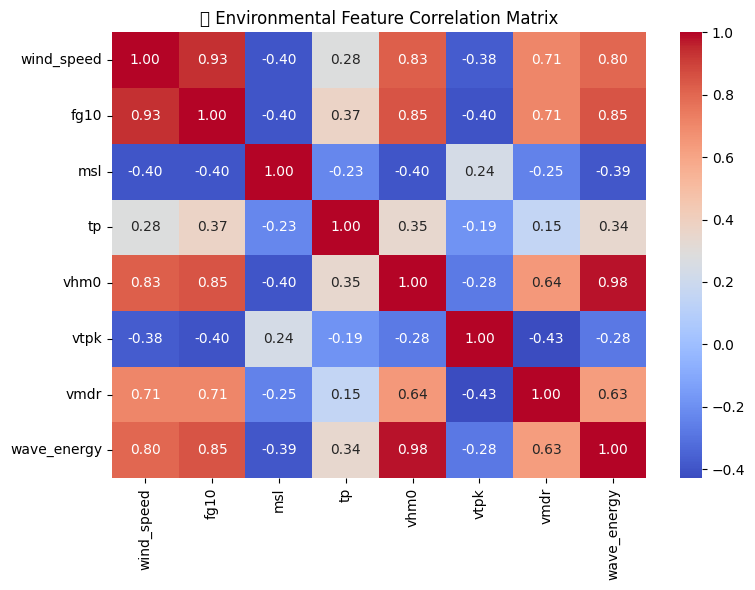

✅ Correlation heatmap saved


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load env features ──
def load_env_features(env_csv):
    df = pd.read_csv(env_csv)
    if "date" not in df.columns:
        raise ValueError("ENV CSV must include a 'date' column")
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.interpolate(method="time").ffill().bfill()
    return df

env_df = load_env_features(ENV_CSV)
env_cols_keep = [c for c in env_df.columns if c not in ["latitude","longitude"]]
env_df = env_df[env_cols_keep]

print("=" * 55)
print("📋 ENVIRONMENTAL FEATURE SUMMARY")
print("=" * 55)
print(env_df.describe().round(4))
print("\n📌 Missing values:")
print(env_df.isna().sum())

# ── Outlier clipping (IQR × 3) — gentle, preserves storm events ──
for col in env_df.select_dtypes(include=[np.number]).columns:
    q1, q3 = env_df[col].quantile(0.25), env_df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 3*iqr, q3 + 3*iqr
    env_df[col] = env_df[col].clip(lower, upper)

print("\n✅ Outlier clipping applied (IQR × 3)")

# ── Correlation heatmap ──
corr_cols = [c for c in ["wind_speed","fg10","msl","tp","vhm0","vtpk","vmdr","wave_energy"]
             if c in env_df.columns]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(env_df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("🌊 Environmental Feature Correlation Matrix")
plt.tight_layout()
fig.savefig(str(OUTPUT_DIR / "correlation_heatmap.png"), dpi=120)
plt.show()
print("✅ Correlation heatmap saved")


In [22]:
# Add rolling features to env (30-day and 90-day means)
# =====================================================
# ✅ USE ENVIRONMENT VARIABLES ONLY (NO ROLLING)
# =====================================================

env_features = env_df.copy()

print("✅ Added cumulative + intensity + variability features")

# Merge: for each shoreline row, pick nearest preceding env row
merged_df = pd.merge_asof(
    shore_df_aug.sort_index(),
    env_features.sort_index(),   # ✅ IMPORTANT
    left_index=True, right_index=True,
    direction="backward",
)
# Env forward-fill (should already be complete)
env_fcols = [c for c in merged_df.columns if c not in transect_cols]
merged_df[env_fcols] = merged_df[env_fcols].ffill().bfill()
merged_df = merged_df.dropna(subset=transect_cols)

feature_cols = [c for c in merged_df.columns if c not in transect_cols]

# ─────────────────────────────
# ADD SHORELINE LAG FEATURES
# (autoregressive memory)
# ─────────────────────────────




TRAIN_FILE = DATA_DIR / "final_training_dataset.csv"
merged_df.to_csv(TRAIN_FILE)


print("✅ Merged dataset:", merged_df.shape)
print("   Feature cols:", len(feature_cols))
print("   Training data saved:", TRAIN_FILE)
merged_df.head()


✅ Added cumulative + intensity + variability features
✅ Merged dataset: (178, 114)
   Feature cols: 14
   Training data saved: data_cache\final_training_dataset.csv


,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,tp,vhm0,vmdr,vtpk,wind_speed,wave_energy,doy_sin,doy_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2010-07-26,-0.000106,-0.000093,-0.000046,-0.000015,-0.000009,-0.000003,0.000003,0.000010,0.000017,0.000024,...,0.000125,1.64625,251.207504,12.85250,3.577817,2.710139,-0.409356,-0.912375,-5.000000e-01,-8.660254e-01
2010-09-08,-0.000118,-0.000100,-0.000028,-0.000005,0.000006,0.000016,0.000025,0.000033,0.000042,0.000051,...,0.000246,1.33000,233.392502,13.65500,3.271050,1.768900,-0.924291,-0.381689,-1.000000e+00,-1.836970e-16
2010-10-22,-0.000129,-0.000106,-0.000011,0.000005,0.000021,0.000035,0.000046,0.000057,0.000067,0.000078,...,0.000056,1.28750,242.610001,5.77000,4.614641,1.657656,-0.933837,0.357698,-8.660254e-01,5.000000e-01
2010-11-16,-0.000033,-0.000031,-0.000015,0.000002,0.000018,0.000034,0.000049,0.000065,0.000080,0.000096,...,0.000264,0.79125,195.587494,10.98125,2.411480,0.626077,-0.699458,0.714673,-5.000000e-01,8.660254e-01
2010-12-09,-0.000273,-0.000250,-0.000182,-0.000144,-0.000117,-0.000090,-0.000071,-0.000082,-0.000093,-0.000089,...,0.001238,1.62000,230.923752,7.56750,3.147732,2.624400,-0.369725,0.929141,-2.449294e-16,1.000000e+00


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor

# ── Chronological 80/20 split — NO leakage ──
n = len(merged_df)
split = int(n * 0.80)

train_df = merged_df.iloc[:split]
test_df  = merged_df.iloc[split:]

X_train = train_df[feature_cols].values
y_train = train_df[transect_cols].values

X_test = test_df[feature_cols].values
y_test = test_df[transect_cols].values

# ── StandardScaler (fit on train only) ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("=" * 50)
print("📂 TRAIN / TEST SPLIT (chronological 80/20)")
print("=" * 50)
print(f"  Total rows  : {n}")
print(f"  Train rows  : {len(train_df)}  ({train_df.index.min().date()} → {train_df.index.max().date()})")
print(f"  Test rows   : {len(test_df)}   ({test_df.index.min().date()} → {test_df.index.max().date()})")
print(f"  Features    : {len(feature_cols)}")
print(f"  Transects   : {len(transect_cols)}")


📂 TRAIN / TEST SPLIT (chronological 80/20)
  Total rows  : 178
  Train rows  : 142  (2010-07-26 → 2022-07-30)
  Test rows   : 36   (2022-08-29 → 2025-07-30)
  Features    : 14
  Transects   : 100


In [24]:
from tqdm import tqdm

# ── Gradient Boosting Regressor per transect ──
# MultiOutputRegressor wraps one GBR per output column.
# GBR handles non-linear seasonal patterns far better than LinearRegression.

print("🔧 Training GradientBoostingRegressor for", len(transect_cols), "transects...")
print("   (This may take 1-3 minutes — GBR fits one tree ensemble per transect)")

base_gbr = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.03,     # slower learning
    max_depth=2,            # shallower trees generalize better
    subsample=0.7,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42,
)

import joblib
MODEL_FILE = DATA_DIR / "trained_model.pkl"
SCALER_FILE = DATA_DIR / "trained_scaler.pkl"

if not QUICK_MODE:
    model = MultiOutputRegressor(base_gbr, n_jobs=-1)
    model.fit(X_train_sc, y_train)
    joblib.dump(model, MODEL_FILE)
    joblib.dump(scaler, SCALER_FILE)
    print("✅ Model training complete! Saved to:", MODEL_FILE)
else:
    assert MODEL_FILE.exists(), "❌ No trained model found. Run Full Rerun first."
    model = joblib.load(MODEL_FILE)
    scaler = joblib.load(SCALER_FILE)
    print("⚡ Loaded pre-trained model from:", MODEL_FILE)


🔧 Training GradientBoostingRegressor for 100 transects...
   (This may take 1-3 minutes — GBR fits one tree ensemble per transect)


⚡ Loaded pre-trained model from: data_cache\trained_model.pkl


In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred_test  = model.predict(X_test_sc)
y_pred_train = model.predict(X_train_sc)

# Per-transect metrics then aggregate
def compute_metrics(y_true, y_pred, label):
    r2_vals   = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    mae_vals  = [mean_absolute_error(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    rmse_vals = [np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])) for i in range(y_true.shape[1])]
    # convert degree errors → metres
    mae_m  = np.mean(mae_vals)  * METERS_PER_DEGREE
    rmse_m = np.mean(rmse_vals) * METERS_PER_DEGREE
    r2_avg = np.mean(r2_vals)
    print(f"\n{'='*50}")
    print(f"📊 {label} SET METRICS (avg over {y_true.shape[1]} transects)")
    print(f"{'='*50}")
    print(f"  R²   (mean)  : {r2_avg:.4f}  (1.0 = perfect)")
    print(f"  MAE  (mean)  : {mae_m:.4f} m")
    print(f"  RMSE (mean)  : {rmse_m:.4f} m")
    return np.array(r2_vals), np.array(mae_vals)*METERS_PER_DEGREE, np.array(rmse_vals)*METERS_PER_DEGREE

r2_tr, mae_tr, rmse_tr = compute_metrics(y_train, y_pred_train, "TRAIN")
r2_te, mae_te, rmse_te = compute_metrics(y_test,  y_pred_test,  "TEST")

import pandas as pd
metrics_df = pd.DataFrame({
    "Metric": ["R² (mean)", "MAE (m)", "RMSE (m)"],
    "Train":  [f"{r2_tr.mean():.4f}", f"{mae_tr.mean():.4f}", f"{rmse_tr.mean():.4f}"],
    "Test":   [f"{r2_te.mean():.4f}", f"{mae_te.mean():.4f}", f"{rmse_te.mean():.4f}"],
})
print("\n")
print(metrics_df.to_string(index=False))



📊 TRAIN SET METRICS (avg over 100 transects)
  R²   (mean)  : 0.7697  (1.0 = perfect)
  MAE  (mean)  : 2.5741 m
  RMSE (mean)  : 3.1561 m

📊 TEST SET METRICS (avg over 100 transects)
  R²   (mean)  : -1.2196  (1.0 = perfect)
  MAE  (mean)  : 5.1802 m
  RMSE (mean)  : 6.3564 m




   Metric  Train    Test
R² (mean) 0.7697 -1.2196
  MAE (m) 2.5741  5.1802
 RMSE (m) 3.1561  6.3564


C:\Users\kanja\AppData\Local\Temp\ipykernel_21896\2985741866.py:112: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.savefig(str(out_path), dpi=120, bbox_inches="tight")


D:\Kanjana\Final_Research\coastalai\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


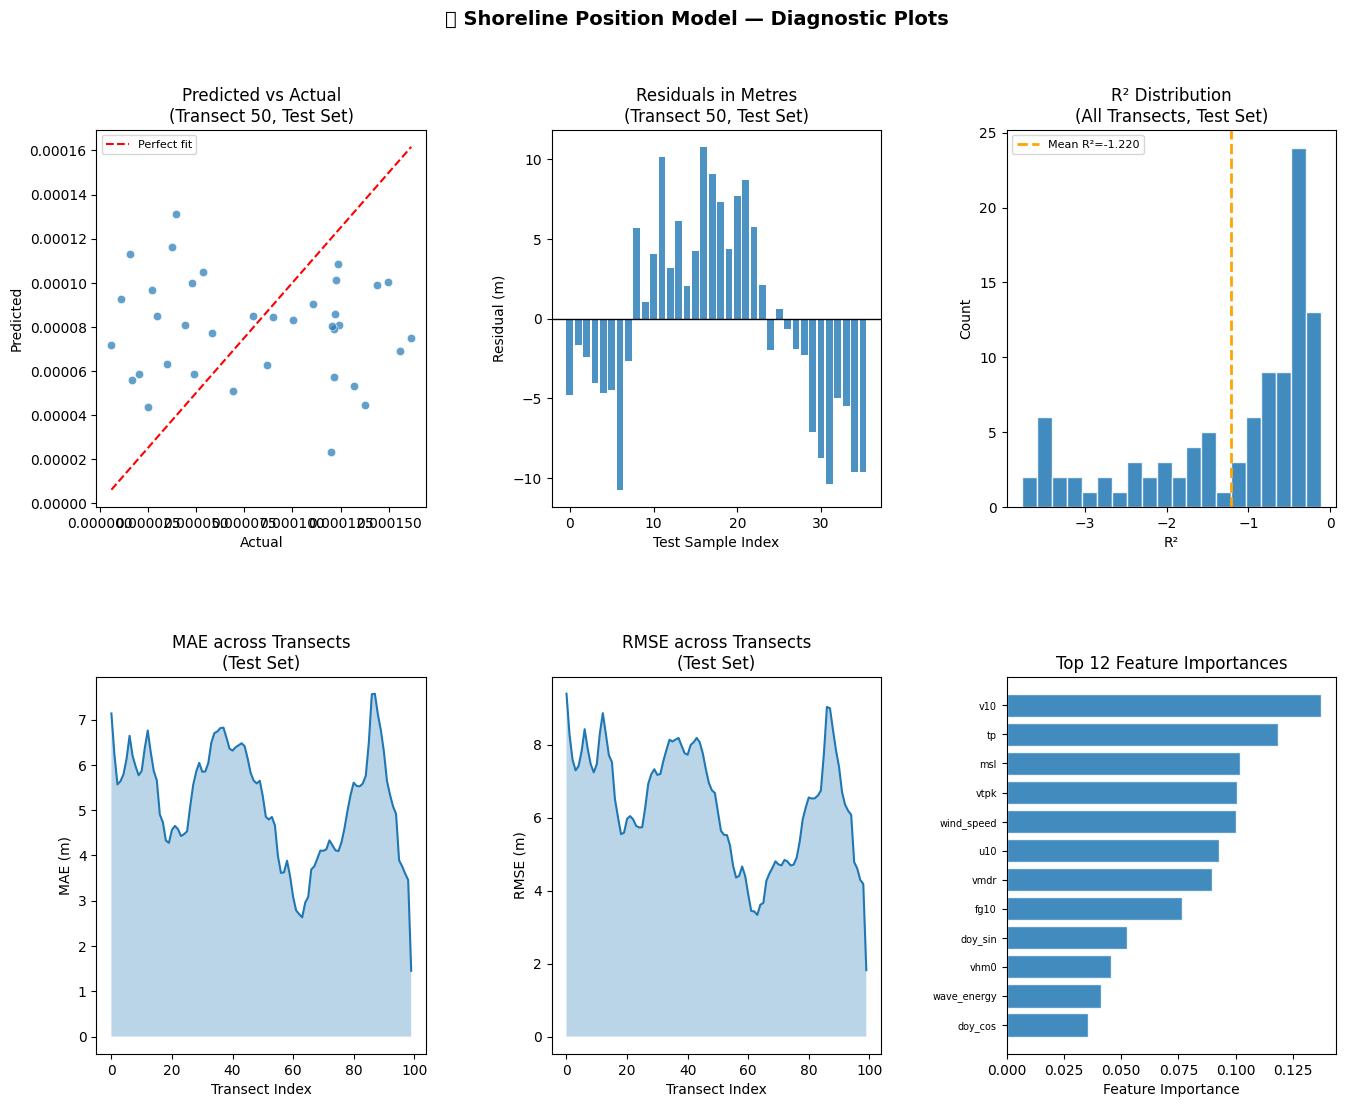

✅ Diagnostic plots saved → data_cache\output_forecasts\diagnostic_plots.png


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# -----------------------
# SAFETY: ensure arrays
# -----------------------
y_test_arr = np.asarray(y_test)
y_pred_arr = np.asarray(y_pred_test)

mid = len(transect_cols) // 2  # representative central transect

# handle NaNs in r2_te (constant series can cause NaN)
r2_te_safe = np.asarray(r2_te, dtype=float)
r2_te_safe = r2_te_safe[~np.isnan(r2_te_safe)]
if len(r2_te_safe) == 0:
    r2_te_safe = np.array([0.0])

# -----------------------
# Feature importance (safe)
# -----------------------
importances = None
try:
    # MultiOutputRegressor -> list of estimators, one per transect
    if hasattr(model, "estimators_") and model.estimators_ is not None:
        fi_list = []
        for est in model.estimators_:
            if hasattr(est, "feature_importances_"):
                fi_list.append(est.feature_importances_)
        if len(fi_list) > 0:
            importances = np.mean(np.vstack(fi_list), axis=0)
except Exception as e:
    print("⚠️ Feature importance skipped:", e)
    importances = None

# -----------------------
# Plot
# -----------------------
fig = plt.figure(figsize=(16, 12))
fig.suptitle("🌊 Shoreline Position Model — Diagnostic Plots", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# (A) Predicted vs Actual — test set (central transect)
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_test_arr[:, mid], y_pred_arr[:, mid], alpha=0.7, edgecolors="white", lw=0.5)
lims = [
    float(min(y_test_arr[:, mid].min(), y_pred_arr[:, mid].min())),
    float(max(y_test_arr[:, mid].max(), y_pred_arr[:, mid].max()))
]
ax1.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
ax1.set_xlabel("Actual")
ax1.set_ylabel("Predicted")
ax1.set_title(f"Predicted vs Actual\n(Transect {mid}, Test Set)")
ax1.legend(fontsize=8)

# (B) Residuals over test time (meters)
ax2 = fig.add_subplot(gs[0, 1])
residuals_m = (y_pred_arr[:, mid] - y_test_arr[:, mid]) * METERS_PER_DEGREE
ax2.bar(range(len(residuals_m)), residuals_m, alpha=0.8)
ax2.axhline(0, color="black", lw=1)
ax2.set_xlabel("Test Sample Index")
ax2.set_ylabel("Residual (m)")
ax2.set_title(f"Residuals in Metres\n(Transect {mid}, Test Set)")

# (C) R² distribution across transects
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(r2_te_safe, bins=20, edgecolor="white", alpha=0.85)
ax3.axvline(np.mean(r2_te_safe), color="orange", lw=2, linestyle="--",
            label=f"Mean R²={np.mean(r2_te_safe):.3f}")
ax3.set_xlabel("R²")
ax3.set_ylabel("Count")
ax3.set_title("R² Distribution\n(All Transects, Test Set)")
ax3.legend(fontsize=8)

# (D) MAE across transects
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(range(len(mae_te)), mae_te, lw=1.5)
ax4.fill_between(range(len(mae_te)), mae_te, alpha=0.3)
ax4.set_xlabel("Transect Index")
ax4.set_ylabel("MAE (m)")
ax4.set_title("MAE across Transects\n(Test Set)")

# (E) RMSE across transects
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(range(len(rmse_te)), rmse_te, lw=1.5)
ax5.fill_between(range(len(rmse_te)), rmse_te, alpha=0.3)
ax5.set_xlabel("Transect Index")
ax5.set_ylabel("RMSE (m)")
ax5.set_title("RMSE across Transects\n(Test Set)")

# (F) Feature importance
ax6 = fig.add_subplot(gs[1, 2])
if importances is None:
    ax6.text(0.05, 0.6,
             "Feature importance not available\n"
             "(either model not fit, or estimator has no feature_importances_).",
             fontsize=10)
    ax6.set_axis_off()
else:
    top_n = min(12, len(importances))
    top_idx = np.argsort(importances)[-top_n:]
    top_names = [feature_cols[i] for i in top_idx]
    top_vals = importances[top_idx]

    ax6.barh(range(top_n), top_vals, edgecolor="white", alpha=0.85)
    ax6.set_yticks(range(top_n))
    ax6.set_yticklabels(top_names, fontsize=7)
    ax6.set_xlabel("Feature Importance")
    ax6.set_title(f"Top {top_n} Feature Importances")

out_path = OUTPUT_DIR / "diagnostic_plots.png"
plt.savefig(str(out_path), dpi=120, bbox_inches="tight")
plt.show()
print("✅ Diagnostic plots saved →", out_path)

In [27]:
from dateutil.relativedelta import relativedelta

# ==============================
# USER INPUT: Forecast Date
# ==============================
today = pd.Timestamp.today().normalize()
target_date = pd.Timestamp(TARGET_DATE)

assert 1 <= (target_date.date() - today.date()).days <= 365, "Must be 1-365 days ahead"

print("✅ Forecast target:", target_date.date())

# ── Seasonal analogue: look back 1 year ──
past_date = target_date - relativedelta(years=1)
X_all = merged_df[feature_cols].copy()   # this is what model expects
# ---- Build feature row for the target date (same columns as training) ----
idx2 = X_all.index.get_indexer([past_date], method="nearest")[0]
future_env_df = X_all.iloc[[idx2]].copy()
future_env_df.index = [target_date]

# Scale + predict
future_env_sc = scaler.transform(future_env_df.values)
pred_vals = model.predict(future_env_sc)[0]
# future_env_df.index = [target_date]

# future_env_sc = scaler.transform(future_env_df[feature_cols].values)
# pred_vals = model.predict(future_env_sc)[0]

# Reconstruct shoreline coordinates
def reconstruct_coords(transect_values, origins, normal):
    return origins + np.outer(transect_values, normal)

coords_forecast = reconstruct_coords(pred_vals, transect_origins, normal_vec)

# Change vs last known
last_known = shore_df_aug.iloc[-1][transect_cols].values
delta = (pred_vals - last_known) * METERS_PER_DEGREE

print("\n" + "="*50)
print("📍 FORECAST SUMMARY")
print("="*50)
print(f"  Target date    : {target_date.date()}")
print(f"  Mean change    : {delta.mean():.2f} m  ({'erosion 🔴' if delta.mean()>0 else 'accretion 🟢'})")
print(f"  Max retreat    : {delta.min():.2f} m")
print(f"  Max advance    : {delta.max():.2f} m")


✅ Forecast target: 2026-07-27



📍 FORECAST SUMMARY
  Target date    : 2026-07-27
  Mean change    : -5.63 m  (accretion 🟢)
  Max retreat    : -15.29 m
  Max advance    : 10.90 m


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# PREDICT ENVIRONMENTAL VARIABLES FOR FORECAST DATE
# Using a ±15-day seasonal window over the last 3 years to produce a
# more robust estimate than a single-day analogue.
# ─────────────────────────────────────────────────────────────────────────────

env_target_cols = [c for c in ["wind_speed","fg10","msl","tp","vhm0","vtpk","vmdr","wave_energy"]
                   if c in env_df.columns]

window_days = 15
years_back  = 3

env_rows = []
for yr in range(1, years_back + 1):
    centre = target_date - relativedelta(years=yr)
    mask   = (env_df.index >= centre - pd.Timedelta(days=window_days)) &              (env_df.index <= centre + pd.Timedelta(days=window_days))
    if mask.sum() > 0:
        env_rows.append(env_df.loc[mask, env_target_cols])

if env_rows:
    env_window = pd.concat(env_rows)
    env_pred = env_window.mean()
    env_std  = env_window.std()
else:
    # fall back to single nearest row
    env_pred = env_df[env_target_cols].iloc[
        env_df.index.get_indexer([past_date], method="nearest")[0]]
    env_std  = pd.Series(0, index=env_target_cols)

# Pretty-print table
UNITS = {
    "wind_speed": "m/s", "fg10": "m/s", "msl": "Pa",
    "tp": "m/day", "vhm0": "m", "vtpk": "s", "vmdr": "°", "wave_energy": "m²"
}
NAMES = {
    "wind_speed": "Wind Speed",  "fg10": "Wind Gust",
    "msl": "Sea Level Pressure", "tp": "Total Precipitation",
    "vhm0": "Sig. Wave Height",  "vtpk": "Wave Peak Period",
    "vmdr": "Wave Direction",    "wave_energy": "Wave Energy Proxy"
}

print("\n" + "="*65)
print(f"🌊 PREDICTED ENVIRONMENTAL CONDITIONS — {target_date.date()}")
print("="*65)
print(f"  (Seasonal window: ±{window_days} days over past {years_back} years)")
print("-"*65)
print(f"  {'Variable':<25} {'Mean':>10} {'Std':>10} {'Unit':>8}")
print("-"*65)
for col in env_target_cols:
    name = NAMES.get(col, col)
    mean_val = env_pred[col]
    std_val  = env_std[col]
    unit     = UNITS.get(col, "")
    print(f"  {name:<25} {mean_val:>10.4f} {std_val:>10.4f} {unit:>8}")
print("="*65)

# Also as a DataFrame for notebook display
env_table = pd.DataFrame({
    "Variable": [NAMES.get(c, c) for c in env_target_cols],
    "Predicted Mean":  [round(env_pred[c], 4) for c in env_target_cols],
    "Std Dev":         [round(env_std[c], 4)  for c in env_target_cols],
    "Unit":            [UNITS.get(c, "")      for c in env_target_cols],
})
env_table



🌊 PREDICTED ENVIRONMENTAL CONDITIONS — 2026-07-27
  (Seasonal window: ±15 days over past 3 years)
-----------------------------------------------------------------
  Variable                        Mean        Std     Unit
-----------------------------------------------------------------
  Wind Speed                    4.2017     1.0049      m/s
  Wind Gust                     8.1239     1.8612      m/s
  Sea Level Pressure        100977.5759   117.9218       Pa
  Total Precipitation           0.0003     0.0003    m/day
  Sig. Wave Height              1.7210     0.2530        m
  Wave Peak Period             12.1766     2.5126        s
  Wave Direction              243.4753    12.6736        °
  Wave Energy Proxy             3.0251     0.8996       m²


,Variable,Predicted Mean,Std Dev,Unit
0,Wind Speed,4.2017,1.0049,m/s
1,Wind Gust,8.1239,1.8612,m/s
2,Sea Level Pressure,100977.5759,117.9218,Pa
3,Total Precipitation,0.0003,0.0003,m/day
4,Sig. Wave Height,1.7210,0.2530,m
5,Wave Peak Period,12.1766,2.5126,s
6,Wave Direction,243.4753,12.6736,°
7,Wave Energy Proxy,3.0251,0.8996,m²


In [29]:
def export_forecast_kml(prediction_coords, date_str, output_path, reference_coords=None):
    pred_str = " ".join([f"{pt[0]},{pt[1]},0" for pt in prediction_coords])
    ref_placemark = ""
    if reference_coords is not None:
        ref_str = " ".join([f"{pt[0]},{pt[1]},0" for pt in reference_coords])
        ref_placemark = f"""
    <Placemark>
      <name>Current Shoreline (Reference)</name>
      <styleUrl>#whiteLine</styleUrl>
      <LineString><tessellate>1</tessellate>
        <coordinates>{ref_str}</coordinates>
      </LineString>
    </Placemark>"""

    kml_content = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
  <Document>
    <name>Forecast {date_str}</name>
    <Style id="redLine"><LineStyle><color>ff0000ff</color><width>3</width></LineStyle></Style>
    <Style id="whiteLine"><LineStyle><color>ffffffff</color><width>2</width></LineStyle></Style>
    <Placemark>
      <name>Forecast {date_str}</name>
      <styleUrl>#redLine</styleUrl>
      <LineString><tessellate>1</tessellate>
        <coordinates>{pred_str}</coordinates>
      </LineString>
    </Placemark>
    {ref_placemark}
  </Document>
</kml>"""
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(kml_content)
    print("✅ KML saved:", output_path)

last_shoreline_coords = shorelines[-1]["coords"]
out_kml = OUTPUT_DIR / f"forecast_{target_date.date()}.kml"
export_forecast_kml(
    prediction_coords=coords_forecast.tolist(),
    date_str=str(target_date.date()),
    output_path=str(out_kml),
    reference_coords=last_shoreline_coords.tolist(),
)
print("\n✅ All outputs saved to:", OUTPUT_DIR.resolve())
print("   • forecast KML     →", out_kml.name)
print("   • diagnostic plots →  diagnostic_plots.png")
print("   • correlation map  →  correlation_heatmap.png")


✅ KML saved: data_cache\output_forecasts\forecast_2026-07-27.kml

✅ All outputs saved to: D:\Kanjana\Final_Research\coastalai\short-term component\data_cache\output_forecasts
   • forecast KML     → forecast_2026-07-27.kml
   • diagnostic plots →  diagnostic_plots.png
   • correlation map  →  correlation_heatmap.png


C:\Users\kanja\AppData\Local\Temp\ipykernel_21896\3014772794.py:32: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


C:\Users\kanja\AppData\Local\Temp\ipykernel_21896\3014772794.py:33: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  fig.savefig(str(OUTPUT_DIR / f"forecast_summary_{target_date.date()}.png"), dpi=120, bbox_inches="tight")


D:\Kanjana\Final_Research\coastalai\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127958 (\N{BEACH WITH UMBRELLA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


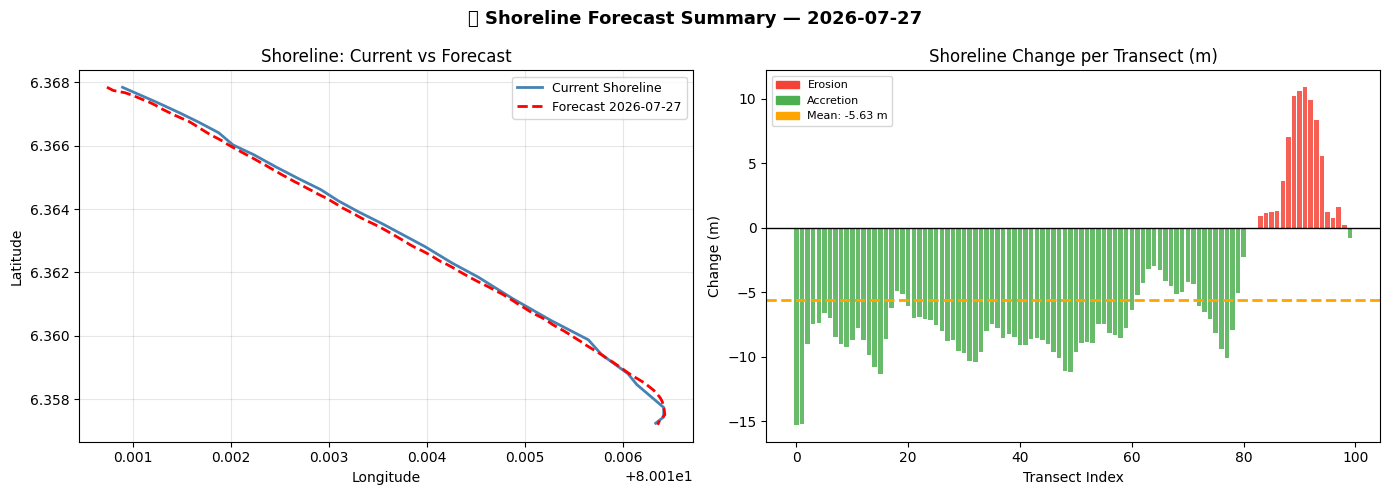

✅ Forecast summary plot saved → data_cache\output_forecasts\forecast_summary_2026-07-27.png


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"🏖️ Shoreline Forecast Summary — {target_date.date()}", fontsize=13, fontweight="bold")

# (A) Shoreline map view
ax = axes[0]
ref_arr = np.array(last_shoreline_coords)
for_arr = coords_forecast
ax.plot(ref_arr[:, 0], ref_arr[:, 1], color="steelblue", lw=2, label="Current Shoreline")
ax.plot(for_arr[:, 0], for_arr[:, 1], color="red",       lw=2, label=f"Forecast {target_date.date()}", linestyle="--")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Shoreline: Current vs Forecast")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# (B) Change per transect (metres)
ax2 = axes[1]
colors = ["#4CAF50" if d < 0 else "#F44336" for d in delta]
ax2.bar(range(len(delta)), delta, color=colors, alpha=0.85, edgecolor="none")
ax2.axhline(0, color="black", lw=1)
ax2.axhline(delta.mean(), color="orange", lw=2, linestyle="--",
            label=f"Mean: {delta.mean():.2f} m")
green_patch = mpatches.Patch(color="#4CAF50", label="Accretion")
red_patch   = mpatches.Patch(color="#F44336", label="Erosion")
ax2.legend(handles=[red_patch, green_patch,
                    mpatches.Patch(color="orange", label=f"Mean: {delta.mean():.2f} m")],
           fontsize=8)
ax2.set_xlabel("Transect Index"); ax2.set_ylabel("Change (m)")
ax2.set_title("Shoreline Change per Transect (m)")

plt.tight_layout()
fig.savefig(str(OUTPUT_DIR / f"forecast_summary_{target_date.date()}.png"), dpi=120, bbox_inches="tight")
plt.show()
print("✅ Forecast summary plot saved →", OUTPUT_DIR / f"forecast_summary_{target_date.date()}.png")


Risk Analysis

In [31]:
import numpy as np
from pathlib import Path

METERS_PER_DEGREE = 111_000.0

def reconstruct_coords(transect_values, origins, normal):
    # origins: (n_transects,2), normal:(2,)
    return origins + np.outer(transect_values, normal)

def classify_risk_levels(delta_m, high_thr=-8.0, med_thr=-3.0):
    """
    delta_m negative = erosion.
    returns: risk_level array int {0:LOW,1:MED,2:HIGH}
    """
    lvl = np.zeros_like(delta_m, dtype=int)
    lvl[delta_m <= med_thr] = 1
    lvl[delta_m <= high_thr] = 2
    return lvl

def contiguous_runs(levels):
    """Yield (start, end, level) for contiguous equal segments [start,end] inclusive."""
    runs = []
    n = len(levels)
    i = 0
    while i < n:
        j = i
        while j + 1 < n and levels[j + 1] == levels[i]:
            j += 1
        runs.append((i, j, int(levels[i])))
        i = j + 1
    return runs

def kml_coords_str(points):
    # points: (k,2) lon,lat
    return " ".join([f"{p[0]},{p[1]},0" for p in points])

def export_wow_risk_kml(
    out_kml_path,
    date_str,
    ref_coords,          # (n,2) reconstructed from last_known
    forecast_coords,      # (n,2) reconstructed from pred_vals
    delta_m,              # (n,) meters
    env_summary_text="",  # optional string (for description)
    top_n_hotspots=7,
    high_thr=-8.0,
    med_thr=-3.0,
    min_run_len=2         # ignore tiny single-transect polygons
):
    out_kml_path = str(out_kml_path)

    # --- Risk levels and runs ---
    risk_lvl = classify_risk_levels(delta_m, high_thr=high_thr, med_thr=med_thr)
    runs = contiguous_runs(risk_lvl)

    # KML colors are AABBGGRR
    # HIGH=red, MED=orange, LOW=green (fill w/ some transparency)
    STYLES = {
        2: {"name":"HIGH", "line":"ff0000ff", "poly":"7f0000ff"},  # red
        1: {"name":"MED",  "line":"ff00a5ff", "poly":"7f00a5ff"},  # orange-ish (BGR)
        0: {"name":"LOW",  "line":"ff00ff00", "poly":"7f00ff00"},  # green
    }

    style_block = []
    for lvl, s in STYLES.items():
        style_block.append(f"""
    <Style id="risk{lvl}">
      <LineStyle><color>{s['line']}</color><width>4</width></LineStyle>
      <PolyStyle><color>{s['poly']}</color><fill>1</fill><outline>1</outline></PolyStyle>
    </Style>""")
    style_block = "\n".join(style_block)

    # Base shoreline styles
    base_styles = f"""
    <Style id="refLine">
      <LineStyle><color>ffffffff</color><width>3</width></LineStyle>
    </Style>
    <Style id="fcLine">
      <LineStyle><color>ff0000ff</color><width>3</width></LineStyle>
    </Style>
    <Style id="hotspot">
      <IconStyle>
        <scale>1.2</scale>
        <Icon><href>http://maps.google.com/mapfiles/kml/paddle/red-circle.png</href></Icon>
      </IconStyle>
      <LabelStyle><scale>0.9</scale></LabelStyle>
    </Style>
    """

    # --- Polygons between ref and forecast for each contiguous risk run ---
    poly_placemarks = []
    n = len(ref_coords)

    for (i, j, lvl) in runs:
        if (j - i + 1) < min_run_len:
            continue

        # Build a “band” polygon between ref and forecast over indices i..j
        ref_seg = ref_coords[i:j+1]
        fc_seg  = forecast_coords[i:j+1][::-1]  # reverse to close nicely

        poly_ring = np.vstack([ref_seg, fc_seg, ref_seg[:1]])  # close ring
        coords = kml_coords_str(poly_ring)

        # Stats for this run
        run_delta = delta_m[i:j+1]
        worst = float(run_delta.min())
        mean  = float(run_delta.mean())

        poly_placemarks.append(f"""
    <Placemark>
      <name>{STYLES[lvl]['name']} Risk Zone ({i}-{j})</name>
      <description><![CDATA[
        <b>Date:</b> {date_str}<br/>
        <b>Transects:</b> {i} to {j}<br/>
        <b>Mean change:</b> {mean:.2f} m<br/>
        <b>Worst retreat:</b> {worst:.2f} m<br/>
      ]]></description>
      <styleUrl>#risk{lvl}</styleUrl>
      <Polygon>
        <tessellate>1</tessellate>
        <outerBoundaryIs>
          <LinearRing>
            <coordinates>{coords}</coordinates>
          </LinearRing>
        </outerBoundaryIs>
      </Polygon>
    </Placemark>
        """)

    poly_placemarks = "\n".join(poly_placemarks)

    # --- Hotspot pins (worst retreat) ---
    # delta_m most negative = worst erosion
    idx_sorted = np.argsort(delta_m)  # ascending => most negative first
    hotspot_idxs = [int(i) for i in idx_sorted[:top_n_hotspots]]

    hotspot_placemarks = []
    for rank, ti in enumerate(hotspot_idxs, start=1):
        p = ref_coords[ti]
        d = float(delta_m[ti])
        # place pin at midpoint between ref and forecast for visibility
        midp = (ref_coords[ti] + forecast_coords[ti]) / 2.0

        # risk name
        lvl = int(classify_risk_levels(np.array([d]), high_thr, med_thr)[0])
        rname = STYLES[lvl]["name"]

        hotspot_placemarks.append(f"""
    <Placemark>
      <name>Hotspot #{rank}: {d:.2f} m ({rname})</name>
      <description><![CDATA[
        <b>Date:</b> {date_str}<br/>
        <b>Transect:</b> {ti}<br/>
        <b>Change:</b> {d:.2f} m<br/>
        <b>Risk:</b> {rname}<br/>
      ]]></description>
      <styleUrl>#hotspot</styleUrl>
      <Point><coordinates>{midp[0]},{midp[1]},0</coordinates></Point>
    </Placemark>
        """)

    hotspot_placemarks = "\n".join(hotspot_placemarks)

    # --- Summary description ---
    mean_change = float(delta_m.mean())
    max_retreat = float(delta_m.min())
    max_advance = float(delta_m.max())

    # Shoreline lines
    ref_line_coords = kml_coords_str(ref_coords)
    fc_line_coords  = kml_coords_str(forecast_coords)

    summary_html = f"""
      <description><![CDATA[
        <h3>Shoreline Risk Forecast</h3>
        <b>Date:</b> {date_str}<br/>
        <b>Mean change:</b> {mean_change:.2f} m<br/>
        <b>Max retreat:</b> {max_retreat:.2f} m<br/>
        <b>Max advance:</b> {max_advance:.2f} m<br/>
        <hr/>
        {env_summary_text}
      ]]></description>
    """

    kml = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
  <Document>
    <name>WOW Risk Map — {date_str}</name>
    {summary_html}

    {base_styles}
    {style_block}

    <!-- Reference shoreline -->
    <Placemark>
      <name>Current Shoreline (Reference)</name>
      <styleUrl>#refLine</styleUrl>
      <LineString><tessellate>1</tessellate>
        <coordinates>{ref_line_coords}</coordinates>
      </LineString>
    </Placemark>

    <!-- Forecast shoreline -->
    <Placemark>
      <name>Forecast Shoreline ({date_str})</name>
      <styleUrl>#fcLine</styleUrl>
      <LineString><tessellate>1</tessellate>
        <coordinates>{fc_line_coords}</coordinates>
      </LineString>
    </Placemark>

    <!-- Risk band polygons -->
    {poly_placemarks}

    <!-- Hotspot pins -->
    {hotspot_placemarks}

  </Document>
</kml>
"""
    with open(out_kml_path, "w", encoding="utf-8") as f:
        f.write(kml)

    print("✅ WOW Risk KML saved:", out_kml_path)


# ============================
# USE IT WITH YOUR VARIABLES
# ============================

# last_known is already:
# last_known = shore_df_aug.iloc[-1][transect_cols].values
# pred_vals is your 1-day forecast output (model.predict(...)[0])
# delta is already meters in your code:
# delta = (pred_vals - last_known) * METERS_PER_DEGREE

ref_coords = reconstruct_coords(last_known, transect_origins, normal_vec)
forecast_coords = reconstruct_coords(pred_vals, transect_origins, normal_vec)

# Optional: put your env_table summary into KML description (simple text)
env_text = ""
try:
    # if you created env_table DataFrame
    rows = []
    for _, r in env_table.iterrows():
        rows.append(f"{r['Variable']}: {r['Predicted Mean']} {r['Unit']}")
    env_text = "<b>Predicted Sea Conditions:</b><br/>" + "<br/>".join(rows)
except:
    env_text = ""

wow_kml = OUTPUT_DIR / f"wow_risk_{target_date.date()}.kml"

ref_date = shore_df_aug.index.max().date()
print("✅ Reference shoreline date (white line):", ref_date)
print("✅ Forecast shoreline date (red line):", target_date.date())

export_wow_risk_kml(
    out_kml_path=wow_kml,
    date_str=str(target_date.date()),
    ref_coords=ref_coords,
    forecast_coords=forecast_coords,
    delta_m=delta,
    env_summary_text=env_text,
    top_n_hotspots=7,
    high_thr=-8.0,
    med_thr=-3.0,
    min_run_len=2
)

✅ Reference shoreline date (white line): 2025-07-30
✅ Forecast shoreline date (red line): 2026-07-27
✅ WOW Risk KML saved: data_cache\output_forecasts\wow_risk_2026-07-27.kml


In [32]:
import numpy as np
import pandas as pd

ENV_CSV = DATA_DIR / "final_era5_cmems_daily_features.csv"

hist = pd.read_csv(ENV_CSV)
hist["date"] = pd.to_datetime(hist["date"])
hist = hist.set_index("date").sort_index()
hist = hist.apply(pd.to_numeric, errors="coerce").dropna()

# If cyclic columns not present (just in case), add them
idx = hist.index
if "doy_sin" not in hist.columns:
    hist["doy_sin"]   = np.sin(2*np.pi*idx.day_of_year/365.0)
    hist["doy_cos"]   = np.cos(2*np.pi*idx.day_of_year/365.0)
    hist["month_sin"] = np.sin(2*np.pi*idx.month/12.0)
    hist["month_cos"] = np.cos(2*np.pi*idx.month/12.0)

print("✅ hist:", hist.shape, hist.index.min().date(), "→", hist.index.max().date())

✅ hist: (13274, 16) 1990-01-01 → 2026-05-05


In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Inputs = things we will have in future (from API) + seasonal time
SURR_X = ["wind_speed","fg10","msl","tp","doy_sin","doy_cos","month_sin","month_cos"]
SURR_X = [c for c in SURR_X if c in hist.columns]

# Outputs = wave variables we need, but won't have in the future
SURR_Y = ["vhm0","vtpk","vmdr"]
assert all(c in hist.columns for c in SURR_Y), f"Missing wave cols in hist: {SURR_Y}"

X = hist[SURR_X].values
Y = hist[SURR_Y].values

surr_scaler = StandardScaler()
X_sc = surr_scaler.fit_transform(X)

base = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.8,
    random_state=42
)

import joblib
WAVE_SURR_FILE   = DATA_DIR / "wave_surr_model.pkl"
WAVE_SURR_SCALER = DATA_DIR / "wave_surr_scaler.pkl"

if not QUICK_MODE:
    wave_surr = MultiOutputRegressor(base, n_jobs=-1)
    wave_surr.fit(X_sc, Y)
    joblib.dump(wave_surr,   WAVE_SURR_FILE)
    joblib.dump(surr_scaler, WAVE_SURR_SCALER)
    print("✅ Trained surrogate saved:", WAVE_SURR_FILE)
else:
    assert WAVE_SURR_FILE.exists(), "❌ No cached wave surrogate. Run Full Rerun first."
    wave_surr   = joblib.load(WAVE_SURR_FILE)
    surr_scaler = joblib.load(WAVE_SURR_SCALER)
    print("⚡ Loaded cached wave surrogate:", WAVE_SURR_FILE)

print("   X:", SURR_X)
print("   Y:", SURR_Y)

⚡ Loaded cached wave surrogate: data_cache\wave_surr_model.pkl
   X: ['wind_speed', 'fg10', 'msl', 'tp', 'doy_sin', 'doy_cos', 'month_sin', 'month_cos']
   Y: ['vhm0', 'vtpk', 'vmdr']


In [34]:
import requests
import pandas as pd
import numpy as np

LAT = 6.5
LON = 80.0

def fetch_weather_forecast_daily(lat, lon, days=16, timezone="Asia/Colombo"):
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "timezone": timezone,
        "forecast_days": int(days),
        "daily": [
            "windspeed_10m_max",
            "windgusts_10m_max",
            "precipitation_sum",
            "pressure_msl_mean",
        ],
    }

    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()

    if "daily" not in data:
        raise ValueError(f"API response missing 'daily': {data}")

    d = data["daily"]
    dates = pd.to_datetime(d["time"])

    # ✅ Make them pandas Series so .fillna() works
    wind = pd.Series(pd.to_numeric(d.get("windspeed_10m_max"), errors="coerce"), index=dates)
    gust = pd.Series(pd.to_numeric(d.get("windgusts_10m_max"), errors="coerce"), index=dates)
    rain = pd.Series(pd.to_numeric(d.get("precipitation_sum"), errors="coerce"), index=dates)
    msl  = pd.Series(pd.to_numeric(d.get("pressure_msl_mean"), errors="coerce"), index=dates)

    df = pd.DataFrame({
        "wind_speed": wind,
        "fg10": gust,
        "tp": rain.fillna(0.0) / 1000.0,  # mm/day → m/day
        "msl": msl.ffill().bfill() * 100.0  # hPa → Pa
    }, index=dates).sort_index()

    df.index.name = "date"
    return df


weather_fc = fetch_weather_forecast_daily(LAT, LON, days=16)

print("✅ weather_fc:", weather_fc.shape,
      weather_fc.index.min().date(),
      "→",
      weather_fc.index.max().date())

weather_fc.head()

✅ weather_fc: (16, 4) 2026-06-27 → 2026-07-12


,wind_speed,fg10,tp,msl
date,,,,
2026-06-27,18.9,39.6,0.0140,100970.0
2026-06-28,19.5,46.4,0.0545,101010.0
2026-06-29,21.8,43.6,0.0274,101000.0
2026-06-30,20.6,43.2,0.0089,101010.0
2026-07-01,14.8,38.5,0.0162,100990.0


In [35]:
weather_fc[["wind_speed","fg10"]] = weather_fc[["wind_speed","fg10"]].ffill().bfill()

print(weather_fc.isna().sum())
print(weather_fc.describe())

wind_speed    0
fg10          0
tp            0
msl           0
dtype: int64
       wind_speed       fg10         tp            msl
count   16.000000  16.000000  16.000000      16.000000
mean    18.568750  42.075000   0.017931  101073.750000
std      2.490172   4.740816   0.013800      82.855296
min     13.700000  28.400000   0.002100  100970.000000
25%     17.550000  39.425000   0.007950  101007.500000
50%     19.200000  43.000000   0.017400  101070.000000
75%     19.625000  45.475000   0.025350  101112.500000
max     22.400000  47.500000   0.054500  101250.000000


In [36]:
# import numpy as np
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# from sklearn.multioutput import MultiOutputRegressor
# from sklearn.ensemble import GradientBoostingRegressor

# ENV_CSV = DATA_DIR / "final_era5_cmems_daily_features.csv"

# hist = pd.read_csv(ENV_CSV)
# hist["date"] = pd.to_datetime(hist["date"])
# hist = hist.set_index("date").sort_index()
# hist = hist.apply(pd.to_numeric, errors="coerce").dropna()

# # Ensure cyclic features exist
# idx = hist.index
# for colname, arr in {
#     "doy_sin":   np.sin(2*np.pi*idx.day_of_year/365.0),
#     "doy_cos":   np.cos(2*np.pi*idx.day_of_year/365.0),
#     "month_sin": np.sin(2*np.pi*idx.month/12.0),
#     "month_cos": np.cos(2*np.pi*idx.month/12.0),
# }.items():
#     if colname not in hist.columns:
#         hist[colname] = arr

# SURR_X = ["wind_speed","fg10","msl","tp","doy_sin","doy_cos","month_sin","month_cos"]
# SURR_Y = ["vhm0","vtpk","vmdr"]

# # keep only available X cols
# SURR_X = [c for c in SURR_X if c in hist.columns]
# missing_y = [c for c in SURR_Y if c not in hist.columns]
# if missing_y:
#     raise ValueError(f"Missing wave columns in hist CSV: {missing_y}")

# X = hist[SURR_X].values
# Y = hist[SURR_Y].values

# surr_scaler = StandardScaler()
# X_sc = surr_scaler.fit_transform(X)

# base = GradientBoostingRegressor(
#     n_estimators=400,
#     learning_rate=0.03,
#     max_depth=2,
#     subsample=0.8,
#     random_state=42
# )

# wave_surr = MultiOutputRegressor(base, n_jobs=-1)
# wave_surr.fit(X_sc, Y)

# print("✅ Wave surrogate trained.")
# print("X:", SURR_X)
# print("Y:", SURR_Y)

# Wave surrogate already trained/loaded in Cell 15 — reusing wave_surr and surr_scaler
print("✅ Wave surrogate ready (reusing from Cell 15)")

✅ Wave surrogate ready (reusing from Cell 15)


In [37]:
def extend_weather_to_30_days(weather_fc, hist, total_days=30):
    cols = ["wind_speed","fg10","msl","tp"]
    start = weather_fc.index.min()
    full_idx = pd.date_range(start, periods=total_days, freq="D")

    out = weather_fc.reindex(full_idx)

    # climatology by day-of-year from history
    h = hist.copy()
    h["doy"] = h.index.dayofyear
    clim_mean = h.groupby("doy")[cols].mean()
    clim_std  = h.groupby("doy")[cols].std().fillna(0)

    # fill missing days
    for d in out.index:
        if pd.isna(out.loc[d, cols]).any():
            doy = d.dayofyear
            mu = clim_mean.loc[doy]
            sd = clim_std.loc[doy]
            noise = np.random.normal(0, 1, size=len(cols))
            out.loc[d, cols] = mu.values + noise * sd.values

    # fill any remaining small NaNs
    out[cols] = out[cols].ffill().bfill()

    return out

weather_fc[["wind_speed","fg10"]] = weather_fc[["wind_speed","fg10"]].ffill().bfill()
weather_30 = extend_weather_to_30_days(weather_fc, hist, total_days=30)

print("✅ weather_30:", weather_30.shape)

✅ weather_30: (30, 4)


In [38]:
# add cyclic features
idx = weather_30.index
weather_30["doy_sin"]   = np.sin(2*np.pi*idx.day_of_year/365.0)
weather_30["doy_cos"]   = np.cos(2*np.pi*idx.day_of_year/365.0)
weather_30["month_sin"] = np.sin(2*np.pi*idx.month/12.0)
weather_30["month_cos"] = np.cos(2*np.pi*idx.month/12.0)

# predict waves
Xf = weather_30[SURR_X].values
Xf_sc = surr_scaler.transform(Xf)
waves_30 = wave_surr.predict(Xf_sc)

future_env_30 = weather_30.copy()
future_env_30[SURR_Y] = waves_30
future_env_30["wave_energy"] = future_env_30["vhm0"] ** 2

print("✅ future_env_30 ready:", future_env_30.shape)
future_env_30.head()

✅ future_env_30 ready: (30, 12)


,wind_speed,fg10,tp,msl,doy_sin,doy_cos,month_sin,month_cos,vhm0,vtpk,vmdr,wave_energy
2026-06-27,18.9,39.6,0.0140,100970.0,0.077386,-0.997001,1.224647e-16,-1.000000,2.929833,12.916580,265.052167,8.583921
2026-06-28,19.5,46.4,0.0545,101010.0,0.060213,-0.998186,1.224647e-16,-1.000000,2.919699,13.110952,265.052167,8.524644
2026-06-29,21.8,43.6,0.0274,101000.0,0.043022,-0.999074,1.224647e-16,-1.000000,2.925344,13.110952,265.179855,8.557636
2026-06-30,20.6,43.2,0.0089,101010.0,0.025818,-0.999667,1.224647e-16,-1.000000,2.920789,13.017814,265.558072,8.531011
2026-07-01,14.8,38.5,0.0162,100990.0,0.008607,-0.999963,-5.000000e-01,-0.866025,2.932637,12.624751,265.223849,8.600358


In [39]:
def detect_events_env(future_env_30):
    # composite hazard score (tune weights later)
    score = (
        2.5 * future_env_30["vhm0"] +
        0.6 * future_env_30["wind_speed"] +
        0.3 * future_env_30["fg10"]
    )

    med = np.median(score)
    mad = np.median(np.abs(score - med))
    thr = med + 3*(mad if mad > 1e-9 else score.std())

    event_days = score[score > thr].index
    if len(event_days) == 0:
        event_days = score.sort_values(ascending=False).head(5).index

    return score, thr, event_days

event_score, event_thr, event_days = detect_events_env(future_env_30)

print("🔥 Event threshold:", float(event_thr))
print("🔥 Event days:", [d.date() for d in event_days])

🔥 Event threshold: 48.98843054027217
🔥 Event days: [datetime.date(2026, 7, 9), datetime.date(2026, 6, 29), datetime.date(2026, 7, 5), datetime.date(2026, 7, 7), datetime.date(2026, 6, 28)]


In [40]:
# Columns to display
DISPLAY_COLS = [
    "wind_speed", "fg10", "tp", "msl",
    "vhm0", "vtpk", "vmdr", "wave_energy"
]

DISPLAY_COLS = [c for c in DISPLAY_COLS if c in future_env_30.columns]

predicted_30_table = future_env_30[DISPLAY_COLS].copy()

# Add event score
predicted_30_table["event_score"] = event_score

# Mark spikes
predicted_30_table["is_spike"] = predicted_30_table["event_score"] > event_thr
predicted_30_table["spike_level"] = np.where(
    predicted_30_table["is_spike"],
    "SPIKE",
    "NORMAL"
)

# Round nicely for frontend
predicted_30_table = predicted_30_table.round({
    "wind_speed": 2,
    "fg10": 2,
    "tp": 6,
    "msl": 1,
    "vhm0": 2,
    "vtpk": 2,
    "vmdr": 1,
    "wave_energy": 3,
    "event_score": 2
})

predicted_30_table.head(30)

,wind_speed,fg10,tp,msl,vhm0,vtpk,vmdr,wave_energy,event_score,is_spike,spike_level
2026-06-27,18.90,39.60,0.014000,100970.0,2.93,12.92,265.1,8.584,30.54,False,NORMAL
2026-06-28,19.50,46.40,0.054500,101010.0,2.92,13.11,265.1,8.525,32.92,False,NORMAL
2026-06-29,21.80,43.60,0.027400,101000.0,2.93,13.11,265.2,8.558,33.47,False,NORMAL
2026-06-30,20.60,43.20,0.008900,101010.0,2.92,13.02,265.6,8.531,32.62,False,NORMAL
2026-07-01,14.80,38.50,0.016200,100990.0,2.93,12.62,265.2,8.600,27.76,False,NORMAL
2026-07-02,19.40,42.80,0.008700,101000.0,2.95,12.82,265.3,8.714,31.86,False,NORMAL
2026-07-03,13.70,38.90,0.024000,101100.0,2.93,13.30,264.7,8.603,27.22,False,NORMAL
2026-07-04,19.00,45.70,0.032400,101030.0,2.94,13.23,265.3,8.657,32.47,False,NORMAL
2026-07-05,19.30,47.20,0.018600,101060.0,2.93,13.33,265.2,8.608,33.07,False,NORMAL
2026-07-06,19.10,38.90,0.002400,101110.0,2.95,10.15,264.7,8.715,30.51,False,NORMAL


In [41]:
# Extract spike rows
spike_summary_table = predicted_30_table[predicted_30_table["is_spike"]].copy()

# If no spike detected, take top 5 highest event_score
if spike_summary_table.empty:
    spike_summary_table = predicted_30_table.sort_values(
        "event_score", ascending=False
    ).head(5).copy()
    spike_summary_table["spike_level"] = "TOP5"

# Add simple driver explanation
drivers = ["vhm0", "wind_speed", "fg10"]

def main_drivers(row):
    vals = {k: row[k] for k in drivers if k in row}
    top = sorted(vals.items(), key=lambda x: x[1], reverse=True)[:2]
    return ", ".join([f"{k}={v:.2f}" for k, v in top])

spike_summary_table["main_drivers"] = spike_summary_table.apply(main_drivers, axis=1)

spike_summary_table

,wind_speed,fg10,tp,msl,vhm0,vtpk,vmdr,wave_energy,event_score,is_spike,spike_level,main_drivers
2026-07-09,22.4,47.5,0.0258,101120.0,2.93,13.36,264.4,8.590,35.02,False,TOP5,"fg10=47.50, wind_speed=22.40"
2026-06-29,21.8,43.6,0.0274,101000.0,2.93,13.11,265.2,8.558,33.47,False,TOP5,"fg10=43.60, wind_speed=21.80"
2026-07-05,19.3,47.2,0.0186,101060.0,2.93,13.33,265.2,8.608,33.07,False,TOP5,"fg10=47.20, wind_speed=19.30"
2026-07-07,20.0,45.4,0.0024,101080.0,2.95,10.18,265.1,8.723,33.00,False,TOP5,"fg10=45.40, wind_speed=20.00"
2026-06-28,19.5,46.4,0.0545,101010.0,2.92,13.11,265.1,8.525,32.92,False,TOP5,"fg10=46.40, wind_speed=19.50"


In [42]:
# ── AUTO-SAVE: Export 30-day forecast data for the dashboard ──
# This cell runs after spike detection and saves CSVs the backend API reads.

import pandas as pd
from pathlib import Path

_out = Path("data_cache") / "output_forecasts"
_out.mkdir(parents=True, exist_ok=True)

# ── 1. Full 30-day env + event score table ──
_p30 = predicted_30_table.copy().reset_index()
_p30.columns = [str(c) for c in _p30.columns]

# Ensure 'date' column exists (index is the date)
if "date" not in _p30.columns and _p30.columns[0] != "date":
    _p30 = _p30.rename(columns={_p30.columns[0]: "date"})

_p30["day"] = range(1, len(_p30) + 1)
_p30.to_csv(_out / "predicted_30days.csv", index=False)
print("✅ Saved predicted_30days.csv:", len(_p30), "rows")

# ── 2. Spike summary table ──
_ss = spike_summary_table.copy().reset_index()
_ss.columns = [str(c) for c in _ss.columns]
if "date" not in _ss.columns and _ss.columns[0] != "date":
    _ss = _ss.rename(columns={_ss.columns[0]: "date"})
_ss.to_csv(_out / "spike_summary.csv", index=False)
print("✅ Saved spike_summary.csv:", len(_ss), "rows")

# ── 3. Environmental conditions (seasonal window mean) ──
import json
env_out = []
for col in env_target_cols:
    env_out.append({
        "variable": col,
        "mean": round(float(env_pred[col]), 4),
        "std":  round(float(env_std[col]),  4),
        "unit": UNITS.get(col, ""),
        "label": NAMES.get(col, col),
    })
with open(_out / "env_conditions.json", "w") as f:
    json.dump(env_out, f, indent=2)
print("✅ Saved env_conditions.json:", len(env_out), "variables")


✅ Saved predicted_30days.csv: 30 rows
✅ Saved spike_summary.csv: 5 rows
✅ Saved env_conditions.json: 8 variables
